In [20]:
# 1. SETUP & IMPORT LIBRARIES
!pip install pymongo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# 2. LOAD & PREPARE DATA
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Standarisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

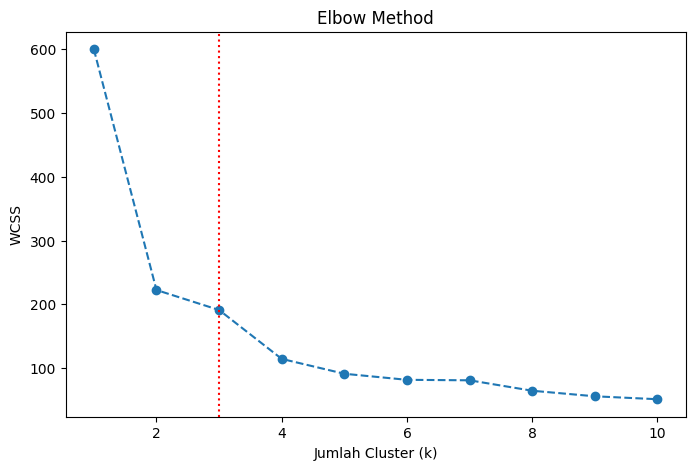

In [21]:
# 3. ELBOW METHOD UNTUK MENENTUKAN K OPTIMAL
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.axvline(x=3, color='r', linestyle=':')
plt.show()

In [22]:
# 4. K-MEANS CLUSTERING (k=3)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster_name'] = df['cluster'].map({0: 'C1', 1: 'C2', 2: 'C3'})

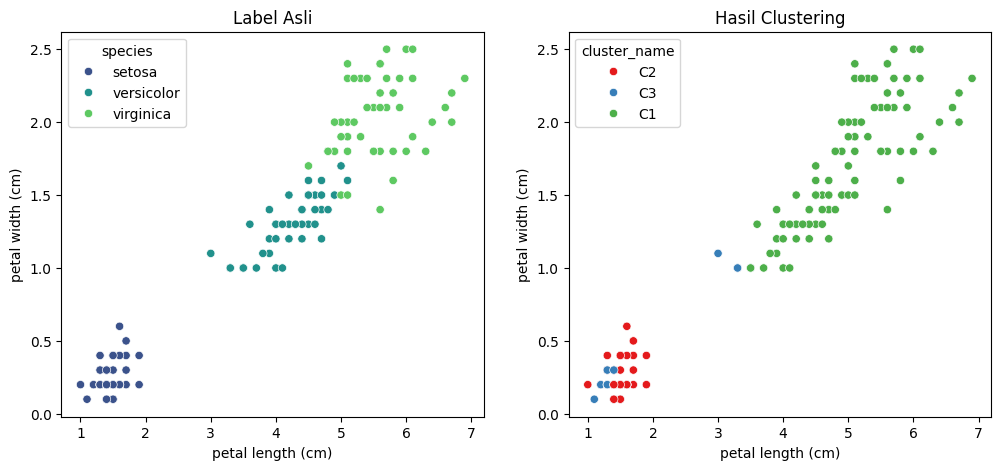

MongoDB (Localhost) Error: localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 2.0s, Topology Description: <TopologyDescription id: 69f85e32486304096bfdcdb4, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>


In [23]:
# 5. VISUALISASI & MONGODB STORAGE
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df, palette='viridis')
plt.title('Label Asli')

plt.subplot(1,2,2)
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='cluster_name', data=df, palette='Set1')
plt.title('Hasil Clustering')
plt.show()

try:
    client = pymongo.MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=2000)
    db = client['clustering']
    collection = db['iris']
    result = collection.insert_many(df.to_dict('records'))
    print(f'Berhasil menyimpan {len(result.inserted_ids)} dokumen!')
except Exception as e:
    print(f'MongoDB (Localhost) Error: {e}')
finally:
    if 'client' in locals(): client.close()

In [24]:
# 6. EVALUASI MODEL
sil_score = silhouette_score(X_scaled, df['cluster'])
ari = adjusted_rand_score(iris.target, df['cluster'])

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette Score: 0.480
Adjusted Rand Index: 0.433


In [ ]:
cluster_profile = df.drop(columns=['species']).groupby('cluster').mean()
print(cluster_profile)

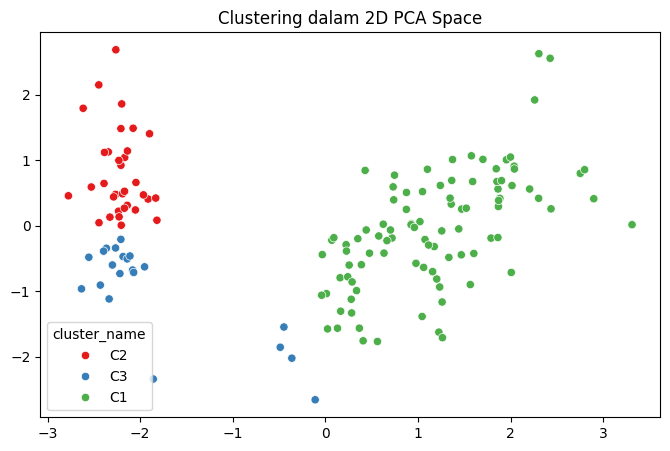

In [25]:
# 7. VISUALISASI PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster_name'], palette='Set1')
plt.title('Clustering dalam 2D PCA Space')
plt.show()